In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('C:/Users/Malik Taha/phishguard-ai')

df = pd.read_csv('data/phishing_data.csv')

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df['result'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (11055, 31)

Label distribution:
result
 1    6157
-1    4898
Name: count, dtype: int64

Missing values: 0

First 5 rows:


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('result', axis=1)
y = df['result']

# Convert -1 to 0 (phishing=0, legitimate=1)
y = y.map({-1: 0, 1: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Label distribution:\n", y.value_counts())

X_train: (8844, 30)
X_test:  (2211, 30)
Label distribution:
 result
1    6157
0    4898
Name: count, dtype: int64


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

print("Training Random Forest...")
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=" * 45)
print("      PHISHGUARD AI RESULTS")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print("=" * 45)
print(classification_report(y_test, y_pred,
      target_names=['Phishing', 'Legitimate']))

Training Random Forest...
      PHISHGUARD AI RESULTS
Accuracy:  97.42%
Precision: 96.96%
Recall:    98.46%
F1-Score:  97.70%
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       980
  Legitimate       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



FileNotFoundError: [Errno 2] No such file or directory: '../docs/confusion_matrix.png'

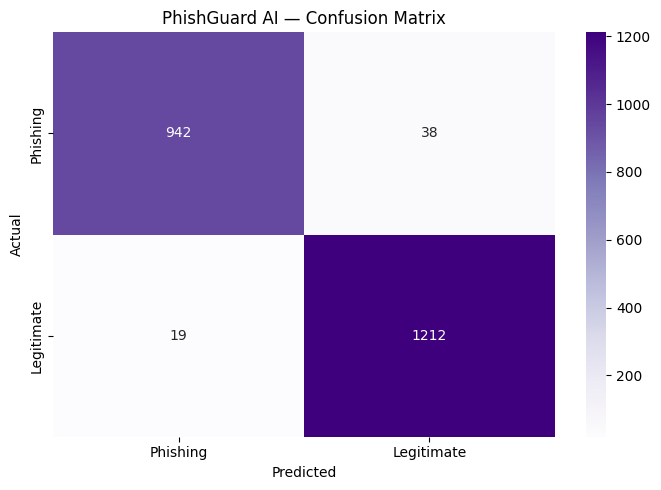

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Phishing', 'Legitimate'],
            yticklabels=['Phishing', 'Legitimate'])
plt.title('PhishGuard AI — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png')
plt.show()